In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/osmi/mental-health-in-tech-survey/survey.csv


# Mental Health in Tech: EDA + Machine Learning

Goal:
Predict whether a person seeks mental health treatment based on workplace and personal factors.

In [8]:
df = pd.read_csv("/kaggle/input/datasets/organizations/osmi/mental-health-in-tech-survey/survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [9]:
# importing libraries 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
# Handle missing values
df = df.dropna()

# Fix gender 
# Remove outliers (age)
df = df[(df['Age'] >= 15) & (df['Age'] <= 70)]

# EDA Summary
## Key Insights from EDA

- Family history strongly affects treatment
- Work interference increases likelihood
- Benefits improve help-seeking behavior

In [11]:
# Convert categorical to numeric
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [12]:
# Define X and y
x = df.drop("treatment", axis=1)
y = df["treatment"]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [14]:
model = LogisticRegression(max_iter=1000)
model 

LogisticRegression(max_iter=1000)

In [15]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(x_test)
y_pred

array([1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.93      0.93      0.93        14

    accuracy                           0.88        17
   macro avg       0.80      0.80      0.80        17
weighted avg       0.88      0.88      0.88        17



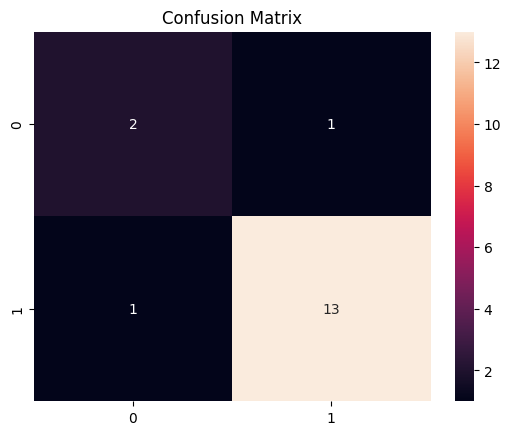

<Figure size 640x480 with 0 Axes>

In [18]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


In [19]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

## Conclusion

- Logistic Regression successfully predicts treatment likelihood
- Family history and work interference are key factors
- Companies can use such models to identify risk and improve support systems